<a href="https://colab.research.google.com/github/MuhammadKhuram/deep-learning-computer-vision/blob/main/googlenet-cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GoogLeNet (Inception v1) Implementation on CIFAR-10**


---
In this notebook, we implement the **GoogLeNet** architecture.

### **Key Improvements in this Implementation:**
*   **Dimensionality Reduction:** 1x1 convolutions are used before 3x3 and 5x5 filters to reduce computational load.
*   **Functional API:** Since the network contains parallel paths that merge, we use the Keras `Model` API instead of `Sequential`.
*   **Global Average Pooling:** Replaces the heavy fully-connected layers to minimize the parameter count.
*   **Batch-Friendly Design:** Optimized for $32 \times 32$ images from the CIFAR-10 dataset.

In [9]:
# ─── ALL IMPORTS AT THE TOP ───────────────────────────────────────────────────

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 65
BATCH_SIZE = 256

## **1. Data Preprocessing and Augmentation**
1.  **Z-Score Normalization:** We standardize the images using the training mean and standard deviation.
2.  **Data Augmentation:** Horizontal flips and height/width shifts are applied to help the complex GoogLeNet architecture generalize better on small images.

In [10]:
# ─── 1. Load Dataset & Preprocessing ──────────────────────────────
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_dataset.load_data()

mean   = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images  = (test_images  - mean) / stddev

train_labels = to_categorical(train_labels, num_classes=10)
test_labels  = to_categorical(test_labels,  num_classes=10)

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_images)

## **2. Defining the Inception Module**
The Inception module allows the model to choose between different filter sizes ($1 \times 1, 3 \times 3, 5 \times 5$) in parallel. The results are concatenated at the end of the module.
*   **Branch 1:** $1 \times 1$ Conv
*   **Branch 2:** $1 \times 1$ Conv (Reduction) $\rightarrow$ $3 \times 3$ Conv
*   **Branch 3:** $1 \times 1$ Conv (Reduction) $\rightarrow$ $5 \times 5$ Conv
*   **Branch 4:** Max Pooling $\rightarrow$ $1 \times 1$ Conv (Projection)

In [11]:
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool_proj):
    # Branch 1
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu')(x)

    # Branch 2
    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu')(conv_3x3)

    # Branch 3
    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu')(conv_5x5)

    # Branch 4
    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu')(pool_proj)

    # Concatenate
    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=-1)
    return output

## **3. Building the GoogLeNet Architecture**
The architecture consists of the **Stem** (initial processing), the **Body** (stack of Inception modules), and the **Head** (Global Average Pooling and Softmax).

In [12]:
input_layer = Input(shape=(32, 32, 3))

# STEM

# The default parameters for Conv2D are:
# - kernel_initializer: 'glorot_uniform'
# - bias_initializer: 'zeros'
# - kernel_regularizer: None
# - bias_regularizer: None
# - activity_regularizer: None
# - kernel_constraint: None
# - bias_constraint: None

x = Conv2D(64, (3, 3), padding='same', activation='relu')(input_layer)
x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

# BODY (Inception 3a, 3b, 4a, 4b, 4c, 4d, 4e, 5a, 5b)

# filters_1x1 = 64: Number of filters for the 1x1 convolution branch
# filters_3x3_reduce = 96: Number of filters for the 1x1 convolution that reduces the depth before the 3x3 convolution
# filters_3x3 = 128: Number of filters for the 3x3 convolution branch
# filters_5x5_reduce = 16: Number of filters for the 1x1 convolution that reduces the depth before the 5x5 convolution
# filters_5x5 = 32: Number of filters for the 5x5 convolution branch
# filters_pool_proj = 32: Number of filters for the 1x1 convolution that projects the output of the max pooling branch

x = inception_module(x, 64, 96, 128, 16, 32, 32) # Inception 3a
x = inception_module(x, 128, 128, 192, 32, 96, 64) # Inception 3b
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x) # Max Pooling after Inception 3b

x = inception_module(x, 192, 96, 208, 16, 48, 64) # Inception 4a
x = inception_module(x, 160, 112, 224, 24, 64, 64) # Inception 4b
x = inception_module(x, 128, 128, 256, 24, 64, 64) # Inception 4c
x = inception_module(x, 112, 144, 288, 32, 64, 64) # Inception 4d
x = inception_module(x, 256, 160, 320, 32, 128, 128) # Inception 4e
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x) # Max Pooling after Inception 4e

x = inception_module(x, 256, 160, 320, 32, 128, 128) # Inception 5a
x = inception_module(x, 384, 192, 384, 48, 128, 128) # Inception 5b

# HEAD
x = GlobalAveragePooling2D()(x) # Reduces the spatial dimensions of the feature maps to 1x1.
x = Dropout(0.4)(x) # Regularization to prevent overfitting. Dropout randomly sets 40% of the input units to 0 during training..
output_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(loss='categorical_crossentropy', optimizer=Adam(0.0001), metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 32, 32,    │    110,784 │ conv2d_56[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 16, 16,    │          0 │ conv2d_57[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 16, 16,    │     18,528 │ max_pooling2d_12… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 16, 16,    │      3,088 │ max_pooling2d_12… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ max_pooling2d_12… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 16, 16,    │     12,352 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 16, 16,    │    110,720 │ conv2d_59[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 16, 16,    │     12,832 │ conv2d_61[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 16, 16,    │      6,176 │ max_pooling2d_13… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 16, 16,    │          0 │ conv2d_58[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_60[0][0],  │
│                     │                   │            │ conv2d_62[0][0],  │
│                     │                   │            │ conv2d_63[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 16, 16,    │     32,896 │ concatenate_9[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 16, 16,    │      8,224 │ concatenate_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 16, 16,    │          0 │ concatenate_9[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 16, 16,    │     32,896 │ concatenate_9[0]… │
│                     │ 128)              │            │                 

 Total params: 5,971,962 (22.78 MB)

 Trainable params: 5,971,962 (22.78 MB)

 Non-trainable params: 0 (0.00 B)

## **4. Model Training**
Training is conducted over 50 epochs using the Adam optimizer.

In [13]:
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    validation_data=(test_images, test_labels),
    epochs=EPOCHS,
    verbose=2
)

Epoch 1/65
196/196 - 139s - 708ms/step - accuracy: 0.2712 - loss: 1.9062 - val_accuracy: 0.3789 - val_loss: 1.6527
Epoch 2/65
196/196 - 54s - 276ms/step - accuracy: 0.4244 - loss: 1.5353 - val_accuracy: 0.4838 - val_loss: 1.3839
Epoch 3/65
196/196 - 54s - 276ms/step - accuracy: 0.4992 - loss: 1.3580 - val_accuracy: 0.5521 - val_loss: 1.2248
Epoch 4/65
196/196 - 54s - 277ms/step - accuracy: 0.5458 - loss: 1.2410 - val_accuracy: 0.5843 - val_loss: 1.1506
Epoch 5/65
196/196 - 54s - 275ms/step - accuracy: 0.5901 - loss: 1.1294 - val_accuracy: 0.6167 - val_loss: 1.0541
Epoch 6/65
196/196 - 54s - 275ms/step - accuracy: 0.6256 - loss: 1.0381 - val_accuracy: 0.6509 - val_loss: 0.9693
Epoch 7/65
196/196 - 54s - 275ms/step - accuracy: 0.6564 - loss: 0.9626 - val_accuracy: 0.6533 - val_loss: 0.9687
Epoch 8/65
196/196 - 54s - 277ms/step - accuracy: 0.6765 - loss: 0.9055 - val_accuracy: 0.6936 - val_loss: 0.8566
Epoch 9/65
196/196 - 54s - 277ms/step - accuracy: 0.6915 - loss: 0.8592 - val_accuracy:

## **5. Training Analysis**
Evaluation of the Loss, Accuracy, and Error rates to determine model performance and stability.

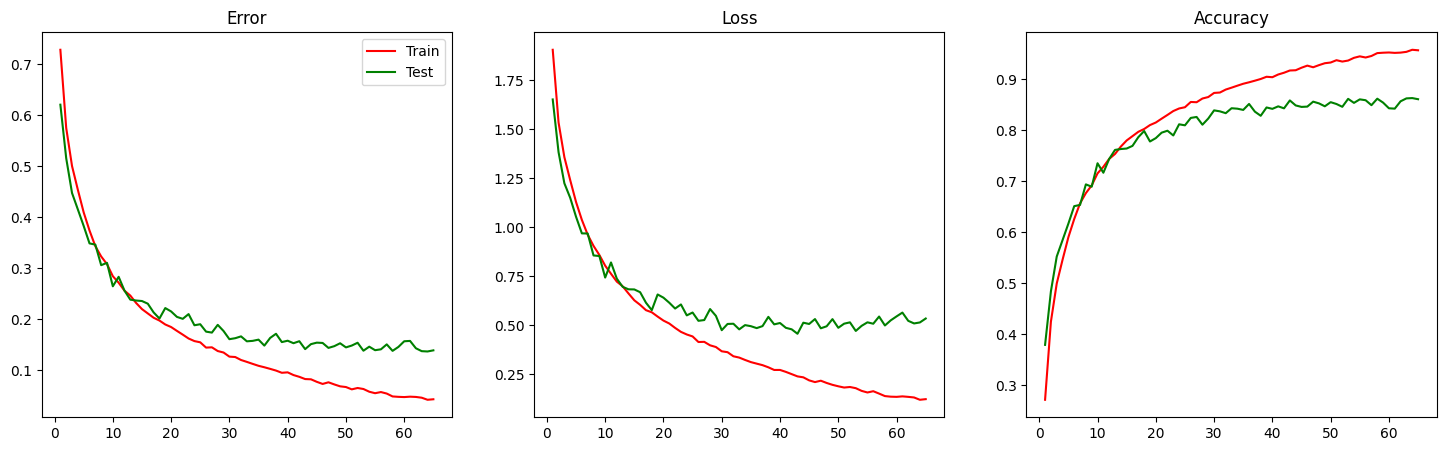

In [14]:
train_error = [1 - acc for acc in history.history['accuracy']]
test_error = [1 - acc for acc in history.history['val_accuracy']]
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1); plt.plot(epochs_range, train_error, 'r', label='Train'); plt.plot(epochs_range, test_error, 'g', label='Test'); plt.title('Error'); plt.legend()
plt.subplot(1, 3, 2); plt.plot(epochs_range, history.history['loss'], 'r'); plt.plot(epochs_range, history.history['val_loss'], 'g'); plt.title('Loss')
plt.subplot(1, 3, 3); plt.plot(epochs_range, history.history['accuracy'], 'r'); plt.plot(epochs_range, history.history['val_accuracy'], 'g'); plt.title('Accuracy')
plt.show()